# Full Bernoulli mask validation

This notebook is the main static validation study under `static/validation_results/`. It reruns the repeated synthetic validation for the Bernoulli-mask model, writes the main recovery summaries to the output folder, and keeps one representative replication with explicit weight and bias recovery details.


In [2]:
import os
import sys
from pathlib import Path
import json
import csv

cwd = Path.cwd().resolve()
repo_root = None
for candidate in (cwd, *cwd.parents):
    if (candidate / "static" / "models.py").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing static/models.py")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import linear_sum_assignment

from static.data import generate_parametric
from static.models import GibbsSamplerLLFM

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)

OUTPUT_DIR = Path("outputs") / "parametric_full"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_SEED = 11


## Setup

Define the synthetic study configuration, helper utilities, and replication routine used by the full Bernoulli-mask validation run.


In [3]:
# Study configuration
study_name = "parametric_full"

# Data-generating parameters
T = 600
S = 4
K = 8
alpha = 4.0
rho = 0.3
sigma_w = 1.0
mu_b = [-3.0] * S
sigma_b = 1.0

# Validation settings
replications = 10
test_fraction = 0.25
chains = 4
n_iter = 2000
burn = 1000
n_subsample = 250
active_threshold = 5

print({
    "study_name": study_name,
    "T": T,
    "S": S,
    "K": K,
    "alpha": alpha,
    "rho": rho,
    "chains": chains,
    "n_iter": n_iter,
    "burn": burn,
    "n_subsample": n_subsample,
    "replications": replications,
})

{'study_name': 'parametric_full', 'T': 600, 'S': 4, 'K': 8, 'alpha': 4.0, 'rho': 0.3, 'chains': 4, 'n_iter': 2000, 'burn': 1000, 'n_subsample': 250, 'replications': 10}


In [4]:
def binary_states(K):
    return ((np.arange(2 ** K)[:, None] >> np.arange(K)) & 1).astype(float)


ALL_Z = binary_states(K)


def align_single_sample(W_sample, W_target):
    cost = np.zeros((W_target.shape[0], W_sample.shape[0]))
    for i in range(W_target.shape[0]):
        for j in range(W_sample.shape[0]):
            cost[i, j] = np.linalg.norm(W_target[i] - W_sample[j])
    _, col_ind = linear_sum_assignment(cost)
    return col_ind


def align_chain_samples(Z_post, W_post, A_post, b_post, W_target):
    Z_aligned = Z_post.copy()
    W_aligned = W_post.copy()
    A_aligned = A_post.copy()
    b_aligned = b_post.copy()

    for draw in range(W_post.shape[0]):
        perm = align_single_sample(W_post[draw] * A_post[draw], W_target)
        Z_aligned[draw] = Z_post[draw][:, perm]
        W_aligned[draw] = W_post[draw][perm]
        A_aligned[draw] = A_post[draw][perm]

    return Z_aligned, W_aligned, A_aligned, b_aligned


def posterior_pi_samples(Z_post, alpha, K, T_train):
    counts = Z_post.sum(axis=1)
    return (counts + alpha / K) / (T_train + 1 + alpha / K)


def corrcoef_flat(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


def mse(a, b):
    return np.mean((np.asarray(a) - np.asarray(b)) ** 2)


def summarize_intervals(samples, truth, level=0.9):
    alpha_tail = (1.0 - level) / 2.0
    low = np.quantile(samples, alpha_tail, axis=0)
    high = np.quantile(samples, 1.0 - alpha_tail, axis=0)
    covered = (truth >= low) & (truth <= high)
    width = np.mean(high - low)
    return {
        "mean": samples.mean(axis=0),
        "low": low,
        "high": high,
        "covered": covered,
        "mean_width": float(width),
    }


def spike_and_slab_summaries(W_samples, A_samples):
    W_eff_samples = W_samples * A_samples
    inclusion_prob = A_samples.mean(axis=0)
    active_counts = A_samples.sum(axis=0)
    conditional_slab_mean = np.divide(
        W_eff_samples.sum(axis=0),
        active_counts,
        out=np.zeros_like(W_eff_samples[0]),
        where=active_counts > 0,
    )
    return {
        "inclusion_prob": inclusion_prob,
        "conditional_slab_mean": conditional_slab_mean,
    }


def effective_baseline_logits(b, pi, W_eff):
    return np.asarray(b) + np.asarray(pi) @ np.asarray(W_eff)


def heldout_predictive_metrics(Y_rows, W_samples, A_samples, b_samples, pi_samples, all_z):
    n_draws = W_samples.shape[0]
    n_rows, s_dim = Y_rows.shape
    probs = np.zeros((n_rows, s_dim))
    row_loglik = np.zeros(n_rows)

    for draw in range(n_draws):
        W_eff = W_samples[draw] * A_samples[draw]
        b = b_samples[draw]
        pi = pi_samples[draw]

        state_log_prior = (all_z * np.log(pi + 1e-12) + (1 - all_z) * np.log(1 - pi + 1e-12)).sum(axis=1)
        state_prior = np.exp(state_log_prior)
        state_prior /= np.sum(state_prior)
        state_probs = expit(all_z @ W_eff + b)
        probs += (state_prior[:, None] * state_probs).sum(axis=0) / n_draws

        for i, y in enumerate(Y_rows):
            bern = (state_probs ** y) * ((1 - state_probs) ** (1 - y))
            row_like = np.prod(bern, axis=1)
            row_loglik[i] += np.log(np.sum(state_prior * row_like) + 1e-12) / n_draws

    brier = np.mean((probs - Y_rows) ** 2)
    return {
        "mean_loglik": float(np.mean(row_loglik)),
        "total_loglik": float(np.sum(row_loglik)),
        "brier": float(brier),
        "mean_probs": probs,
    }


def split_rhat(chains_array):
    chains_array = np.asarray(chains_array)
    m, n = chains_array.shape
    half = n // 2
    split = np.concatenate([chains_array[:, :half], chains_array[:, half:2 * half]], axis=0)
    n_split = split.shape[1]
    chain_means = split.mean(axis=1)
    B = n_split * np.var(chain_means, ddof=1)
    W = np.mean(np.var(split, axis=1, ddof=1))
    var_hat = ((n_split - 1) / n_split) * W + B / n_split
    return float(np.sqrt(var_hat / W))


def autocorr(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    if max_lag is None:
        max_lag = min(n - 1, 200)
    var = np.dot(x, x) / n
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        out[lag] = np.dot(x[:-lag], x[lag:]) / ((n - lag) * var)
    return out


def ess_per_chain(x):
    ac = autocorr(x)
    tau = 1.0
    for lag in range(1, len(ac) - 1, 2):
        pair_sum = ac[lag] + ac[lag + 1]
        if pair_sum <= 0:
            break
        tau += 2 * pair_sum
    return float(len(x) / tau)


def pooled_ess(chains_array):
    return float(np.sum([ess_per_chain(chain) for chain in chains_array]))


def active_feature_count(Z_post, threshold):
    usage = Z_post.sum(axis=1)
    return (usage > threshold).sum(axis=1)


def scalar_diagnostics(chain_results, active_threshold):
    trace_stats = {
        "W_eff[0,0]": np.stack([(chain["W"] * chain["A"])[:, 0, 0] for chain in chain_results]),
        "W_eff[0,1]": np.stack([(chain["W"] * chain["A"])[:, 0, 1] for chain in chain_results]),
        "b[0]": np.stack([chain["b"][:, 0] for chain in chain_results]),
        "pi[0]": np.stack([chain["pi"][:, 0] for chain in chain_results]),
        "active_features": np.stack([active_feature_count(chain["Z"], active_threshold) for chain in chain_results]),
    }
    out = {}
    for name, values in trace_stats.items():
        out[name] = {
            "rhat": split_rhat(values),
            "ess": pooled_ess(values),
        }
    return out, trace_stats

In [5]:
def run_single_replication(rep_id, base_seed):
    rng = np.random.default_rng(base_seed)
    Y, Z_true, W_true, b_true, p_true = generate_parametric(
        T=T,
        S=S,
        K=K,
        alpha=alpha,
        rho=rho,
        sigma_w=sigma_w,
        mu_b=mu_b,
        sigma_b=sigma_b,
    )

    perm = rng.permutation(T)
    n_test = int(T * test_fraction)
    test_idx = perm[:n_test]
    train_idx = perm[n_test:]
    Y_train = Y[train_idx]
    Y_test = Y[test_idx]

    chain_results = []

    for chain in range(chains):
        np.random.seed(base_seed + 1000 + chain)
        sampler = GibbsSamplerLLFM(
            Data=Y_train,
            K=K,
            rho=rho,
            alpha=alpha,
            sigma_w=sigma_w,
            sigma_b=sigma_b,
            mu_b=mu_b,
            n_iter=n_iter,
            burn=burn,
            n_subsample=n_subsample,
        )
        sampler.run(verbose=False)
        sampler.get_posterior_samples()

        Z_post, W_post, A_post, b_post = align_chain_samples(
            sampler.good_samples_Z,
            sampler.good_samples_W,
            sampler.good_samples_A,
            sampler.good_samples_b,
            W_true,
        )

        pi_post = posterior_pi_samples(Z_post, alpha=alpha, K=K, T_train=Y_train.shape[0])
        predictive = heldout_predictive_metrics(Y_test, W_post, A_post, b_post, pi_post, ALL_Z)

        chain_results.append({
            "Z": Z_post,
            "W": W_post,
            "A": A_post,
            "b": b_post,
            "pi": pi_post,
            "predictive": predictive,
        })

    W_all = np.concatenate([chain["W"] for chain in chain_results], axis=0)
    A_all = np.concatenate([chain["A"] for chain in chain_results], axis=0)
    b_all = np.concatenate([chain["b"] for chain in chain_results], axis=0)
    pi_all = np.concatenate([chain["pi"] for chain in chain_results], axis=0)
    W_eff_all = W_all * A_all

    W_eff_mean = W_eff_all.mean(axis=0)
    b_mean = b_all.mean(axis=0)
    pi_mean = pi_all.mean(axis=0)
    spike_summaries = spike_and_slab_summaries(W_all, A_all)
    true_baseline_logits = effective_baseline_logits(b_true, p_true, W_true)
    est_baseline_logits = effective_baseline_logits(b_mean, pi_mean, W_eff_mean)

    interval_W = summarize_intervals(W_eff_all, W_true)
    interval_b = summarize_intervals(b_all, b_true)
    interval_pi = summarize_intervals(pi_all, p_true)

    predictive_loglik = np.array([chain["predictive"]["mean_loglik"] for chain in chain_results])
    predictive_brier = np.array([chain["predictive"]["brier"] for chain in chain_results])
    diagnostics, trace_stats = scalar_diagnostics(chain_results, active_threshold)
    active_counts = np.concatenate([active_feature_count(chain["Z"], active_threshold) for chain in chain_results])

    metrics = {
        "replication": rep_id,
        "W_mse": float(mse(W_eff_mean, W_true)),
        "W_corr": float(corrcoef_flat(W_eff_mean, W_true)),
        "b_mse": float(mse(b_mean, b_true)),
        "b_corr": float(corrcoef_flat(b_mean, b_true)),
        "pi_mse": float(mse(pi_mean, p_true)),
        "pi_corr": float(corrcoef_flat(pi_mean, p_true)),
        "baseline_logit_mse": float(mse(est_baseline_logits, true_baseline_logits)),
        "baseline_logit_corr": float(corrcoef_flat(est_baseline_logits, true_baseline_logits)),
        "W_width90": interval_W["mean_width"],
        "b_width90": interval_b["mean_width"],
        "pi_width90": interval_pi["mean_width"],
        "heldout_loglik": float(predictive_loglik.mean()),
        "heldout_brier": float(predictive_brier.mean()),
        "rhat_max": float(max(item["rhat"] for item in diagnostics.values())),
        "ess_min": float(min(item["ess"] for item in diagnostics.values())),
        "active_features_mean": float(active_counts.mean()),
        "active_features_std": float(active_counts.std(ddof=1)),
    }

    details = {
        "truth": {
            "W_true": W_true.tolist(),
            "b_true": b_true.tolist(),
            "p_true": p_true.tolist(),
            "baseline_logits": true_baseline_logits.tolist(),
        },
        "posterior_mean": {
            "W_eff": W_eff_mean.tolist(),
            "b": b_mean.tolist(),
            "pi": pi_mean.tolist(),
            "baseline_logits": est_baseline_logits.tolist(),
        },
        "spike_summaries": {
            "inclusion_prob": spike_summaries["inclusion_prob"].tolist(),
            "conditional_slab_mean": spike_summaries["conditional_slab_mean"].tolist(),
        },
        "intervals": {
            "W_eff": {k: v.tolist() if hasattr(v, 'tolist') else v for k, v in interval_W.items()},
            "b": {k: v.tolist() if hasattr(v, 'tolist') else v for k, v in interval_b.items()},
            "pi": {k: v.tolist() if hasattr(v, 'tolist') else v for k, v in interval_pi.items()},
        },
        "diagnostics": diagnostics,
        "trace_preview": {key: value[:, :20].tolist() for key, value in trace_stats.items()},
    }

    return metrics, details

In [6]:
replication_metrics = []
replication_details = []

for rep in range(replications):
    print(f"Running replication {rep + 1}/{replications}")
    metrics, details = run_single_replication(rep_id=rep, base_seed=MASTER_SEED + 100 * rep)
    replication_metrics.append(metrics)
    replication_details.append(details)

print("Finished all replications.")

Running replication 1/10
Running replication 2/10
Running replication 3/10
Running replication 4/10
Running replication 5/10
Running replication 6/10
Running replication 7/10
Running replication 8/10
Running replication 9/10
Running replication 10/10
Finished all replications.


In [7]:
metric_names = [
    "W_mse", "W_corr", "b_mse", "b_corr", "pi_mse", "pi_corr",
    "baseline_logit_mse", "baseline_logit_corr",
    "W_width90", "b_width90", "pi_width90",
    "heldout_loglik", "heldout_brier",
    "rhat_max", "ess_min",
    "active_features_mean", "active_features_std",
]

summary = {}
for name in metric_names:
    values = np.array([row[name] for row in replication_metrics], dtype=float)
    summary[name] = {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
        "min": float(values.min()),
        "max": float(values.max()),
        "median": float(np.median(values)),
    }

W_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["W_eff"]["covered"], dtype=float) for d in replication_details]), axis=0)
b_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["b"]["covered"], dtype=float) for d in replication_details]), axis=0)
pi_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["pi"]["covered"], dtype=float) for d in replication_details]), axis=0)

coverage_summary = {
    "W": {
        "mean": float(W_coverage_by_param.mean()),
        "min": float(W_coverage_by_param.min()),
        "max": float(W_coverage_by_param.max()),
        "matrix": W_coverage_by_param.tolist(),
    },
    "b": {
        "mean": float(b_coverage_by_param.mean()),
        "min": float(b_coverage_by_param.min()),
        "max": float(b_coverage_by_param.max()),
        "vector": b_coverage_by_param.tolist(),
    },
    "pi": {
        "mean": float(pi_coverage_by_param.mean()),
        "min": float(pi_coverage_by_param.min()),
        "max": float(pi_coverage_by_param.max()),
        "vector": pi_coverage_by_param.tolist(),
    },
}

print("Aggregate validation summary")
print("----------------------------")
for name in metric_names:
    s = summary[name]
    print(f"{name:24s} mean={s['mean']:.4f} std={s['std']:.4f} min={s['min']:.4f} max={s['max']:.4f}")

print("\nPer-parameter 90% interval coverage averaged across replications")
print("-------------------------------------------------------------")
print(f"W mean coverage:  {coverage_summary['W']['mean']:.4f}  (min={coverage_summary['W']['min']:.4f}, max={coverage_summary['W']['max']:.4f})")
print(f"b mean coverage:  {coverage_summary['b']['mean']:.4f}  (min={coverage_summary['b']['min']:.4f}, max={coverage_summary['b']['max']:.4f})")
print(f"pi mean coverage: {coverage_summary['pi']['mean']:.4f}  (min={coverage_summary['pi']['min']:.4f}, max={coverage_summary['pi']['max']:.4f})")

Aggregate validation summary
----------------------------
W_mse                    mean=0.1291 std=0.0987 min=0.0299 max=0.3379
W_corr                   mean=0.8107 std=0.0745 min=0.6531 max=0.9124
b_mse                    mean=0.2362 std=0.1886 min=0.0532 max=0.7288
b_corr                   mean=0.9381 std=0.0500 min=0.8346 max=0.9989
pi_mse                   mean=0.0789 std=0.0259 min=0.0282 max=0.1101
pi_corr                  mean=0.1916 std=0.3550 min=-0.4904 max=0.5839
baseline_logit_mse       mean=0.0479 std=0.0362 min=0.0158 max=0.1245
baseline_logit_corr      mean=0.9899 std=0.0067 min=0.9774 max=0.9990
W_width90                mean=1.2397 std=0.0881 min=1.1603 max=1.4498
b_width90                mean=1.9544 std=0.1348 min=1.7766 max=2.2421
pi_width90               mean=0.8900 std=0.0117 min=0.8750 max=0.9153
heldout_loglik           mean=-1.1528 std=0.4258 min=-1.9412 max=-0.6642
heldout_brier            mean=0.0838 std=0.0383 min=0.0395 max=0.1571
rhat_max                 mea

## Aggregate findings and representative replication

This section converts the replication metrics into saved headline summaries and keeps one representative replication with explicit weight and bias recovery details.


In [8]:
good_recovery = np.mean([row["W_corr"] >= 0.7 for row in replication_metrics])
good_bias_recovery = np.mean([row["b_corr"] >= 0.7 for row in replication_metrics])
good_convergence = np.mean([row["rhat_max"] <= 1.05 for row in replication_metrics])

W_corr_values = np.array([row["W_corr"] for row in replication_metrics], dtype=float)
representative_idx = int(np.argmin(np.abs(W_corr_values - np.median(W_corr_values))))
representative_metrics = replication_metrics[representative_idx]
representative_details = replication_details[representative_idx]

main_findings = {
    "study_name": study_name,
    "configuration": {
        "T": T,
        "S": S,
        "K": K,
        "alpha": alpha,
        "rho": rho,
        "chains": chains,
        "n_iter": n_iter,
        "burn": burn,
        "n_subsample": n_subsample,
        "replications": replications,
    },
    "summary": summary,
    "coverage_summary": coverage_summary,
    "headline": {
        "share_W_corr_ge_0.7": float(good_recovery),
        "share_b_corr_ge_0.7": float(good_bias_recovery),
        "share_rhat_max_le_1.05": float(good_convergence),
    },
    "representative_replication": {
        "index": representative_idx,
        "metrics": representative_metrics,
        "truth": representative_details["truth"],
        "posterior_mean": representative_details["posterior_mean"],
        "spike_summaries": representative_details["spike_summaries"],
        "recovery_delta": {
            "W_eff_minus_true": (
                np.array(representative_details["posterior_mean"]["W_eff"]) - np.array(representative_details["truth"]["W_true"])
            ).tolist(),
            "b_minus_true": (
                np.array(representative_details["posterior_mean"]["b"]) - np.array(representative_details["truth"]["b_true"])
            ).tolist(),
            "baseline_logits_minus_true": (
                np.array(representative_details["posterior_mean"]["baseline_logits"]) - np.array(representative_details["truth"]["baseline_logits"])
            ).tolist(),
        },
    },
}

print("Headline findings")
print("-----------------")
print(json.dumps(main_findings["headline"], indent=2))
print(f"Representative replication index: {representative_idx}")


Headline findings
-----------------
{
  "share_W_corr_ge_0.7": 0.9,
  "share_b_corr_ge_0.7": 1.0,
  "share_rhat_max_le_1.05": 0.5
}
Representative replication index: 0


## Output files

Write the aggregate metrics, representative replication details, and short findings summary to the static validation output folder.


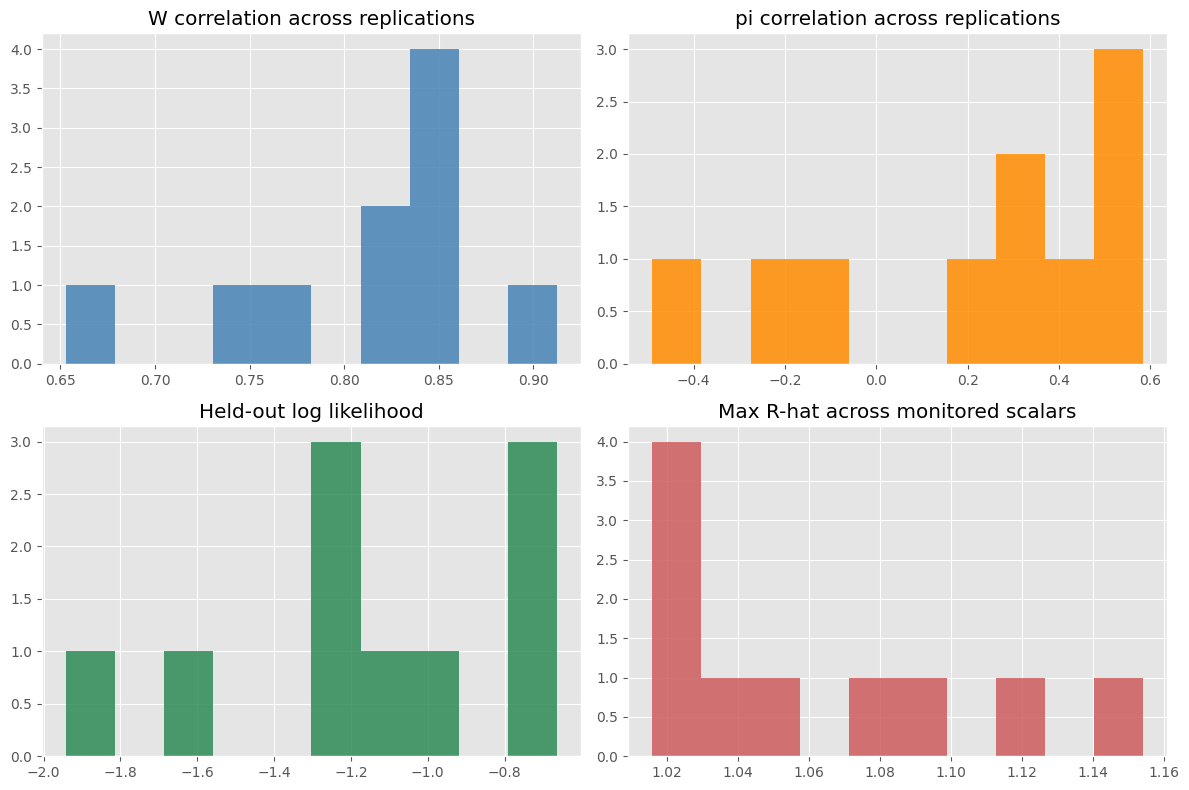

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist([row["W_corr"] for row in replication_metrics], bins=10, color="steelblue", alpha=0.85)
axes[0, 0].set_title("W correlation across replications")

axes[0, 1].hist([row["pi_corr"] for row in replication_metrics], bins=10, color="darkorange", alpha=0.85)
axes[0, 1].set_title("pi correlation across replications")

axes[1, 0].hist([row["heldout_loglik"] for row in replication_metrics], bins=10, color="seagreen", alpha=0.85)
axes[1, 0].set_title("Held-out log likelihood")

axes[1, 1].hist([row["rhat_max"] for row in replication_metrics], bins=10, color="indianred", alpha=0.85)
axes[1, 1].set_title("Max R-hat across monitored scalars")

fig.tight_layout()

In [10]:
csv_path = OUTPUT_DIR / f"{study_name}_metrics.csv"
json_path = OUTPUT_DIR / f"{study_name}_summary.json"
details_path = OUTPUT_DIR / f"{study_name}_replications.json"
txt_path = OUTPUT_DIR / f"{study_name}_findings.txt"

fieldnames = list(replication_metrics[0].keys())
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(replication_metrics)

with json_path.open("w") as f:
    json.dump(main_findings, f, indent=2)

with details_path.open("w") as f:
    json.dump(replication_details, f, indent=2)

with txt_path.open("w") as f:
    f.write(f"Study: {study_name}\n")
    f.write("Configuration:\n")
    for key, value in main_findings["configuration"].items():
        f.write(f"  {key}: {value}\n")

    f.write("\nHeadline findings:\n")
    f.write(f"  Share of replications with W correlation >= 0.7: {main_findings['headline']['share_W_corr_ge_0.7']:.4f}\n")
    f.write(f"  Share of replications with b correlation >= 0.7: {main_findings['headline']['share_b_corr_ge_0.7']:.4f}\n")
    f.write(f"  Share of replications with max R-hat <= 1.05: {main_findings['headline']['share_rhat_max_le_1.05']:.4f}\n")
    f.write("\nBias identifiability note:\n")
    f.write("  Raw b recovery can look unstable because the model may trade off intercepts against average latent contributions.\n")
    f.write("  The combined baseline-logit diagnostics b + pi^T W_eff are therefore included as the more identifiable dimension-level offset summary.\n")

    f.write("\nPrimary recovery metrics:\n")
    for name in ["W_mse", "W_corr", "b_mse", "b_corr", "baseline_logit_mse", "baseline_logit_corr", "heldout_loglik", "heldout_brier", "rhat_max", "ess_min"]:
        s = summary[name]
        f.write(
            f"  {name}: mean={s['mean']:.4f}, std={s['std']:.4f}, min={s['min']:.4f}, max={s['max']:.4f}, median={s['median']:.4f}\n"
        )

    f.write("\nSecondary feature-probability metrics:\n")
    for name in ["pi_mse", "pi_corr"]:
        s = summary[name]
        f.write(
            f"  {name}: mean={s['mean']:.4f}, std={s['std']:.4f}, min={s['min']:.4f}, max={s['max']:.4f}, median={s['median']:.4f}\n"
        )

    f.write("\nAverage 90% interval width across replications:\n")
    for name in ["W_width90", "b_width90", "pi_width90"]:
        s = summary[name]
        f.write(
            f"  {name}: mean={s['mean']:.4f}, std={s['std']:.4f}, min={s['min']:.4f}, max={s['max']:.4f}, median={s['median']:.4f}\n"
        )

    f.write("\nPer-parameter 90% interval coverage averaged across replications:\n")
    f.write(
        f"  W: mean={coverage_summary['W']['mean']:.4f}, min={coverage_summary['W']['min']:.4f}, max={coverage_summary['W']['max']:.4f}\n"
    )
    f.write(
        f"  b: mean={coverage_summary['b']['mean']:.4f}, min={coverage_summary['b']['min']:.4f}, max={coverage_summary['b']['max']:.4f}\n"
    )
    f.write(
        f"  pi: mean={coverage_summary['pi']['mean']:.4f}, min={coverage_summary['pi']['min']:.4f}, max={coverage_summary['pi']['max']:.4f}\n"
    )

    rep = main_findings['representative_replication']
    f.write(f"\nRepresentative replication: {rep['index']}\n")
    f.write("Representative metrics:\n")
    for key, value in rep['metrics'].items():
        if key == 'replication':
            continue
        f.write(f"  {key}: {value:.4f}\n" if isinstance(value, float) else f"  {key}: {value}\n")
    f.write("\nRepresentative true parameters:\n")
    f.write(f"  W_true:\n{np.array2string(np.array(rep['truth']['W_true']), precision=3)}\n")
    f.write(f"  b_true:\n{np.array2string(np.array(rep['truth']['b_true']), precision=3)}\n")
    f.write(f"  p_true:\n{np.array2string(np.array(rep['truth']['p_true']), precision=3)}\n")
    f.write(f"  baseline_logits_true:\n{np.array2string(np.array(rep['truth']['baseline_logits']), precision=3)}\n")
    f.write("\nRepresentative posterior means:\n")
    f.write(f"  W_eff_mean:\n{np.array2string(np.array(rep['posterior_mean']['W_eff']), precision=3)}\n")
    f.write(f"  b_mean:\n{np.array2string(np.array(rep['posterior_mean']['b']), precision=3)}\n")
    f.write(f"  pi_mean:\n{np.array2string(np.array(rep['posterior_mean']['pi']), precision=3)}\n")
    f.write(f"  baseline_logits_mean:\n{np.array2string(np.array(rep['posterior_mean']['baseline_logits']), precision=3)}\n")
    f.write("\nRepresentative spike-and-slab summaries:\n")
    f.write(f"  inclusion_prob:\n{np.array2string(np.array(rep['spike_summaries']['inclusion_prob']), precision=3)}\n")
    f.write(f"  conditional_slab_mean:\n{np.array2string(np.array(rep['spike_summaries']['conditional_slab_mean']), precision=3)}\n")

    f.write("\nRepresentative recovery deltas (posterior mean minus truth):\n")
    f.write(f"  W_eff_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['W_eff_minus_true']), precision=3)}\n")
    f.write(f"  b_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['b_minus_true']), precision=3)}\n")
    f.write(f"  baseline_logits_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['baseline_logits_minus_true']), precision=3)}\n")

print("Wrote outputs:")
print(csv_path)
print(json_path)
print(details_path)
print(txt_path)


Wrote outputs:
outputs/parametric_full/parametric_full_metrics.csv
outputs/parametric_full/parametric_full_summary.json
outputs/parametric_full/parametric_full_replications.json
outputs/parametric_full/parametric_full_findings.txt


## Notes

- The quick notebook is useful for fast iteration on one dataset. This full notebook is the one to trust for claims about robustness.
- The exact predictive marginalization scales as `2^K`, so keep `K` modest if runtime becomes painful.
- If recovery is still unstable, tune `alpha`, `rho`, and `K` jointly rather than one at a time: they all affect effective sparsity and feature splitting.